In [159]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

import matplotlib.pyplot as plt

In [160]:
appdata = pd.read_csv('../Output/london_app_selected_converted.csv')

appdata = appdata[~appdata['year'].isin([2000, 2001])]

In [161]:
nan_count_description = appdata['description'].isna().sum()
print(nan_count_description)

48


In [162]:
nan_count_decision = appdata['decision'].isna().sum()
print(nan_count_decision)

89577


For the `decision` column, there are more than 70 percent of the data is missing.

In [163]:
nan_count_status = appdata['status'].isna().sum()
print(nan_count_status)

53


For the `status` column, there are only 53 missing values.

In [164]:
counts_d = appdata['decision'].value_counts()
print(counts_d)

decision
Approved                                 20810
Refused                                   2236
Comment Issued                             512
Withdrawn                                  273
Not Required                               175
REFUSED                                     87
GWLA                                        79
Closed                                      70
Declined to Determine                       52
Allowed                                     49
Called in by Secretary of State             24
GWGC                                        16
Opinion Issued                               8
WDNA                                         6
No Objection to Proposal (OBS only)          3
Referred to Mayor                            3
Pre-application Advice Case Completed        2
Split Decision                               1
GWUU                                         1
PER                                          1
LAPSED                                       1
Unkn

In [165]:
counts_s = appdata['status'].value_counts()
print(counts_s)

status
Completed                          69197
Lapsed                             17255
Superseded                         13674
Commenced                           9097
Approved                            2113
Refused                              994
Unknown                              372
Dismissed                            371
Withdrawn                            251
Closed                               188
Allowed                               64
REFUSED                               53
Appeal In Progress                    53
Appeal in Progress                    37
Not Required                          37
lapsed                                37
Insufficient Fee                      23
Called in by Secretary of State       20
Application Under Consideration       12
                                      11
CGP                                   10
Comment Issued                        10
GRANTD                                 8
Appeal Closed                          6
GRANT    

In these two columns -- `decision` and `status`, the descriptions are highly inconsistent. Excessive data fragmentation affects data quality, so these two features will be ignored.

In [166]:
# Count total number of rows in the dataset
total_count = len(appdata)

# Count how many rows have NaN (missing) values in 'description'
missing_count = appdata['description'].isna().sum()

# Fill NaNs with empty string and convert everything to string type
appdata['description_str'] = appdata['description'].notna().fillna('').astype(str)

# Count how many rows are empty strings (or only whitespace)
empty_string_count = (appdata['description_str'].str.strip() == '').sum()

# Print summary
print(f"Total rows: {total_count}")
print(f"NaN description rows: {missing_count} ({missing_count / total_count:.2%})")
print(f"Empty string description rows: {empty_string_count} ({empty_string_count / total_count:.2%})")

Total rows: 113988
NaN description rows: 48 (0.04%)
Empty string description rows: 0 (0.00%)


In [167]:
appdata.dropna(subset=['description'], inplace=True)
appdata.drop(columns=['description_str'], inplace=True)

At the first stage, just simply clean up the data format.

In [168]:
import re

def clean_text_basic(text):
    # Remove newline characters and everything after (keep only the first paragraph)
    text = re.sub(r"\n.*", "", text)

    # Remove control characters like carriage returns and tabs
    text = re.sub(r"[\r\t]+", " ", text)

    # Normalize expressions like "4 x one-bedroom" to "4-x-one-bedroom"
    text = re.sub(r"(\d+)\s*x\s*([a-zA-Z0-9\-]+)", r"\1-x-\2", text, flags=re.IGNORECASE)

    # Merge multiple spaces into one
    text = re.sub(r"\s{2,}", " ", text)

    # Trim leading and trailing whitespace
    text = text.strip()

    # If ends with English closing bracket, keep it and add a period
    if re.search(r"[)\]\}]$", text):
        text += "."
    else:
        # Otherwise, clean trailing punctuation and ensure proper sentence end
        text = re.sub(r"[.?!]+$|[;:,\-–—]+$|[^a-zA-Z0-9\s\)\]\}]+$", "", text).strip()
        if text:
            text += "."


    return text

appdata['description_'] = appdata['description'].fillna("").apply(clean_text_basic)
appdata = appdata[appdata['description_'] != ""]

agg_text_train = appdata[['lsoa21cd', 'year', 'description_']]
agg_text_train.columns = ['LSOA21CD', 'year', 'description']

In [169]:
agg_text_train_sample = agg_text_train.sample(n=10000, random_state=42)

In [170]:
agg_text_train.to_csv('../Output/london_app_doc.csv', index=False)
agg_text_train_sample.to_csv('../Output/london_app_s_doc.csv', index=False)

In [171]:
docs_origin = agg_text_train['description'].tolist()
docs_sample = agg_text_train_sample['description'].tolist()

Generate word embeddings in advance and save them (**using raw text, which will be further cleaned up later**).

In [173]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(docs_origin, show_progress_bar=True)
embeddings_sample = embedding_model.encode(docs_sample, show_progress_bar=True)

Batches:   0%|          | 0/3561 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [174]:
print(embeddings.shape)
print(embeddings_sample.shape)

(113938, 384)
(10000, 384)


In [175]:
np.save('../Model/emb_all-MiniLM-L6-v2.npy', embeddings)
np.save('../Model/emb_s_all-MiniLM-L6-v2.npy', embeddings_sample)

Total unique tokens: 197786


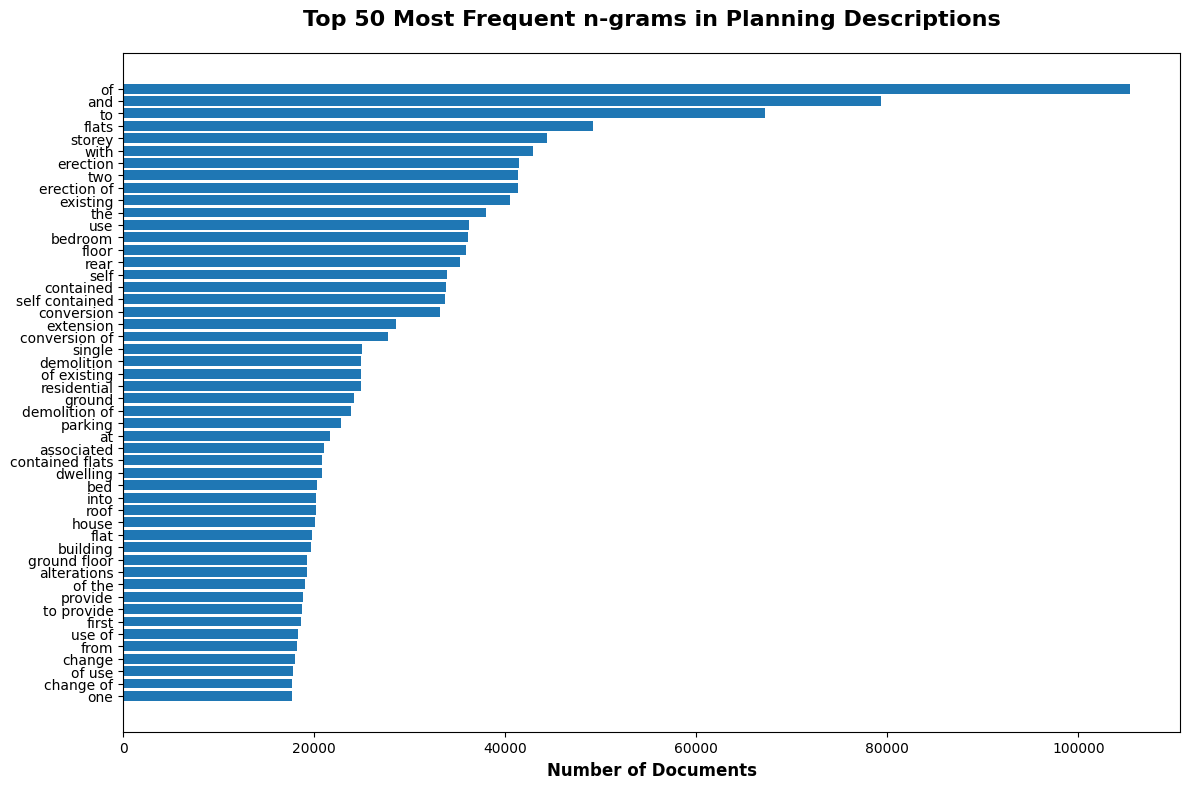

In [176]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer to extract unigrams and bigrams, excluding English stopwords
vectorizer = CountVectorizer(
    # stop_words='english',
    ngram_range=(1, 2)  # Extract both unigrams and bigrams
)

# Generate the document-term matrix (rows = documents, columns = n-grams)
X = vectorizer.fit_transform(docs_origin)

# Get the list of extracted n-grams
ngrams = vectorizer.get_feature_names_out()

print("Total unique tokens:", len(ngrams))

# Compute document frequency for each n-gram
doc_freq = (X > 0).sum(axis=0).A1  # .A1 flattens the sparse matrix to a 1D array

# Create a DataFrame containing n-grams and their corresponding document frequencies
df_freq = pd.DataFrame({
    'ngram': ngrams,
    'doc_freq': doc_freq
})

# Sort by document frequency and select the top 50 most frequent n-grams
df_freq_sorted = df_freq.sort_values(by='doc_freq', ascending=False).head(50)

# Visualize the top 50 n-grams using a horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(df_freq_sorted['ngram'][::-1], df_freq_sorted['doc_freq'][::-1])  # Reverse for top-down order
plt.xlabel("Number of Documents", fontsize=12, fontweight='bold')
plt.title("Top 50 Most Frequent n-grams in Planning Descriptions", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [177]:
# vectorizer = CountVectorizer(stop_words='english')

# tokenizer = vectorizer.build_tokenizer()
# stopwords = vectorizer.get_stop_words()

# agg_text_train['tokens'] = agg_text_train['description'].apply(lambda x: [token for token in tokenizer(x.lower()) if token not in stopwords])
# agg_text_train_sample['tokens'] = agg_text_train_sample['description'].apply(lambda x: [token for token in tokenizer(x.lower()) if token not in stopwords])

# import ast

# def parse_tokens(x):
#     if isinstance(x, str):
#         return ast.literal_eval(x)
#     else:
#         return x

# agg_text_train['tokens'] = agg_text_train['tokens'].apply(parse_tokens)
# agg_text_train_sample['tokens'] = agg_text_train_sample['tokens'].apply(parse_tokens)

# print(type(agg_text_train['tokens'].iloc[0]))
# print(agg_text_train['tokens'].head(10))

# agg_text_train.to_csv('../Output/london_app_tokens.csv', index=False)
# agg_text_train_sample.to_csv('../Output/london_app_s_tokens.csv', index=False)

In [178]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print('Number of stop words in sklearn:', len(ENGLISH_STOP_WORDS), '\n')
print(sorted(ENGLISH_STOP_WORDS))

Number of stop words in sklearn: 318 

['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amoungst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 'behind', 'being', 'below', 'beside', 'besides', 'between', 'beyond', 'bill', 'both', 'bottom', 'but', 'by', 'call', 'can', 'cannot', 'cant', 'co', 'con', 'could', 'couldnt', 'cry', 'de', 'describe', 'detail', 'do', 'done', 'down', 'due', 'during', 'each', 'eg', 'eight', 'either', 'eleven', 'else', 'elsewhere', 'empty', 'enough', 'etc', 'even', 'ever', 'every', 'everyone', 'everything', 'everywhere', 'except', 'few', 'fifteen', 'fifty', 'fill', 'find', 'fire', 'first', 'five', 'for', 'former', 'formerly', 'forty', 'found', 'four', 'from', '